In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Check for hardware acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Running on device: {device}")




Running on device: cpu


In [9]:

# 1. GET THE DATA
# Normalize the RGB numbers from [0, 255] down to [-1, 1] for better AI math
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



c:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [10]:
# 2. THE ARCHITECTURE
class ColorCNN(nn.Module):
    def __init__(self):
        super(ColorCNN, self).__init__()
        # Conv Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Conv Block 2 (Deepening the network)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # The Brain (Voting Layer)
        self.flatten = nn.Flatten()
        # Image went from 32x32 -> 16x16 -> 8x8. 
        # 32 kernels * 8 height * 8 width = 2048 flat inputs
        self.fc1 = nn.Linear(2048, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10) 

    def forward(self, x):
        x = self.pool(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc2(self.relu3(self.fc1(x)))
        return x

ai_model = ColorCNN().to(device)

# 3. THE RULES
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ai_model.parameters(), lr=0.001)

# 4. TRAINING LOOP
epochs = 5
print("\n--- Starting CNN Training ---")
for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in train_loader:
        # Move data to the same device as the model
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = ai_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Average Loss: {running_loss/len(train_loader):.4f}")

# 5. THE FINAL EXAM
print("\n--- Testing on Unseen Images ---")
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = ai_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Final CNN Accuracy: {100 * correct / total:.2f}%")


--- Starting CNN Training ---
Epoch 1/5 | Average Loss: 1.4287
Epoch 2/5 | Average Loss: 1.1003
Epoch 3/5 | Average Loss: 0.9556
Epoch 4/5 | Average Loss: 0.8519
Epoch 5/5 | Average Loss: 0.7750

--- Testing on Unseen Images ---
Final CNN Accuracy: 69.79%


--- AI VISUAL TEST ---


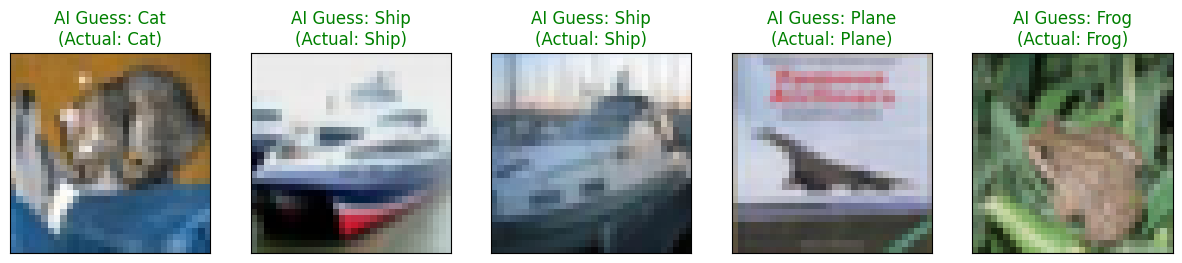

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The exact 10 categories the AI was trained to recognize
classes = ('Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck')

# 2. Grab ONE batch of unseen test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# 3. Feed them to the AI for a blind guess
images_gpu = images.to(device)
outputs = ai_model(images_gpu)
_, predicted = torch.max(outputs, 1) # Get the highest probability guess

# 4. Visualization Setup
fig = plt.figure(figsize=(15, 4))
print("--- AI VISUAL TEST ---")

# Let's look at the first 5 images in this batch
for idx in range(5):
    ax = fig.add_subplot(1, 5, idx+1, xticks=[], yticks=[])
    
    # UN-NORMALIZE: We previously squished the colors to [-1, 1] for math. 
    # We must undo that math to make the image look normal to human eyes.
    img = images[idx] / 2 + 0.5     
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Get the English words for the AI's guess and the actual true label
    true_name = classes[labels[idx]]
    guess_name = classes[predicted[idx]]
    
    # Color the text Green if the AI is right, Red if it is wrong
    color = "green" if true_name == guess_name else "red"
    ax.set_title(f"AI Guess: {guess_name}\n(Actual: {true_name})", color=color)

plt.show()